In [20]:
# importing the necessary packages 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import requests
from PIL import Image
from io import BytesIO

In [21]:
# going to read in the data 
images = pd.read_csv("https://raw.githubusercontent.com/randa-ama/DS6050-Final-Project/refs/heads/main/data/images.csv")
styles = pd.read_csv("https://raw.githubusercontent.com/randa-ama/DS6050-Final-Project/refs/heads/main/data/styles_FIXED.csv")

In [22]:
# lets take a peak at the data 
images.head()

,filename,link
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...


In [23]:
# lets take a peak at the data 
styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,NaN,NaN
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,NaN,NaN
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,NaN,NaN
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,NaN,NaN
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,NaN,NaN


In [24]:
# i see there is two unnamed columns at the end of the styles dataset; going to iterate through those two columns to see if there are is any data in those columns or its just a function of the csv
unnamed_cols = ['Unnamed: 10','Unnamed: 11']
for cols in unnamed_cols:
    print(styles[cols].isna().sum())

44425
44444


In [25]:
# going to look at the shape for the images and styles csv
print(images.shape)
print(styles.shape)

(44446, 2)
(44446, 12)


In [26]:
# so the images and the styles csv are the same length so i need to see whats in the unnamed columns 
styles['Unnamed: 10'].value_counts()

Unnamed: 10
 Cufflink and Pocket Square Combo Set    14
 its all about me White T-shirt           1
 Blue and Orange Casual Shoes             1
 Silver and Copper Toned Earrings         1
Laugh                                     1
Do It My Way T-shirt                      1
 I don't use it anyway Black T-shirt      1
 Life                                     1
Name: count, dtype: int64

In [27]:
styles['Unnamed: 11'].value_counts()

Unnamed: 11
Love Flip-flops      1
 Laugh Flip Flops    1
Name: count, dtype: int64

In [28]:
# going to simply drop the unnamed columns and only use the product display name column 
styles = styles.drop(columns=['Unnamed: 10','Unnamed: 11'])
styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [29]:
# creating an images subset 
images_sub = images.sample(20)
images_sub

,filename,link
13447,12864.jpg,http://assets.myntassets.com/v1/images/style/p...
27797,57077.jpg,http://assets.myntassets.com/v1/images/style/p...
39227,11369.jpg,http://assets.myntassets.com/v1/images/style/p...
2538,34406.jpg,http://assets.myntassets.com/v1/images/style/p...
5360,51436.jpg,http://assets.myntassets.com/v1/images/style/p...
38453,10761.jpg,http://assets.myntassets.com/v1/images/style/p...
40146,13053.jpg,http://assets.myntassets.com/v1/images/style/p...
35705,5593.jpg,http://assets.myntassets.com/assets/images/559...
34407,40043.jpg,http://assets.myntassets.com/v1/images/style/p...
12771,53801.jpg,http://assets.myntassets.com/v1/images/style/p...


In [11]:
# ! pip install torchvision

In [ ]:
# creating a function to read in the images csv
from PIL import Image
from io import BytesIO
def load_image(url):
    try:
        response = requests.get(url, timeout=10)
        return Image.open(BytesIO(response.content)).convert("RGB")
    except:
        return None

images_sub["image_data"] = images_sub["link"].apply(load_image)

In [15]:
images_sub['image_data']

14787    <PIL.Image.Image image mode=RGB size=1080x1440...
43094    <PIL.Image.Image image mode=RGB size=1080x1440...
41245    <PIL.Image.Image image mode=RGB size=1800x2400...
9693     <PIL.Image.Image image mode=RGB size=1080x1440...
29723    <PIL.Image.Image image mode=RGB size=1080x1440...
38708    <PIL.Image.Image image mode=RGB size=1800x2400...
10224    <PIL.Image.Image image mode=RGB size=360x480 a...
36441    <PIL.Image.Image image mode=RGB size=1080x1440...
40797    <PIL.Image.Image image mode=RGB size=1080x1440...
10828    <PIL.Image.Image image mode=RGB size=1080x1440...
1786     <PIL.Image.Image image mode=RGB size=1800x2400...
12139    <PIL.Image.Image image mode=RGB size=1800x2400...
39529    <PIL.Image.Image image mode=RGB size=1080x1440...
9103     <PIL.Image.Image image mode=RGB size=1800x2400...
41678    <PIL.Image.Image image mode=RGB size=1800x2400...
15097    <PIL.Image.Image image mode=RGB size=1080x1440...
20824    <PIL.Image.Image image mode=RGB size=1800x2400.

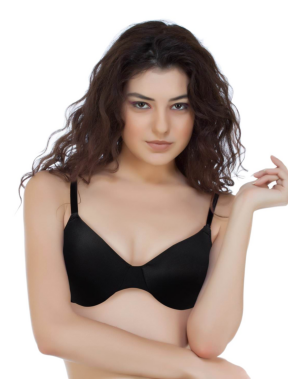

In [ ]:
# how to actually look at the images 
img = images_sub.iloc[0]["image_data"]
plt.imshow(img)
plt.axis("off")
plt.show()